## Egyetlen neuron tanítása

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [39]:
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X = X.T  # (2, 300)
y = y.reshape(1, -1)  # (1, 300)

Sigmoid:

$\sigma(z) = \cfrac{1}{1 + e^{-z}}$

Veszteség: bináris keresztentrópia:

$L = -\frac{1}{n} \sum \left( y \log(\hat{y}) + (1-y) \log(1-\hat{y}) \right)$

**Numerikus stabilitás**

A bináris kereszt-entrópia számítása során logaritmust veszünk a predikált $\hat{y}$ értékekre és az $1 - \hat{y}$ kifejezésre. 

Ha `y_pred` értéke pontosan 0 vagy 1 lenne, akkor:

- `log(0)` → matematikailag értelmetlen ($-\infty$),
- ami számítógépes környezetben hibát vagy `NaN` értéket eredményezne.

Ennek elkerülésére egy nagyon kis értéket, $10^{-8}$ (`1e-8`) adunk hozzá a két kifejezéshez, így biztosítjuk, hogy a logaritmus bemenete mindig pozitív legyen.

In [40]:
np.random.seed(42)
w = np.random.randn(2, 1) * 0.01 # (2, 1)
b = 0

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def loss(y_true, y_pred):
    n = y_true.shape[1]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8)) / n
    return loss

$z = \mathbf{w}^T X + b$

$\hat{\mathbf{y}} = \sigma(\mathbf{z)}$

Gradiensek:

$\cfrac{\partial L}{\partial w} = \frac{1}{n} X^T (\hat{y} - y)$
  
$\cfrac{\partial L}{\partial b} = \frac{1}{n} \sum (\hat{y} - y)$

In [41]:
learning_rate = 0.1
epochs = 5000
losses = []

for epoch in range(epochs):
    z = np.dot(w.T, X) + b  # (1, 300)
    y_pred = sigmoid(z)     # (1, 300)

    l = loss(y, y_pred)
    losses.append(l)

    n = X.shape[1]
    dz = y_pred - y            # (1, 300)
    dw = np.dot(X, dz.T) / n   # (2, 1)
    db = np.sum(dz) / n        # skalar

    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {l:.4f}")

Epoch 0, Loss: 0.6916
Epoch 100, Loss: 0.3913
Epoch 200, Loss: 0.3450
Epoch 300, Loss: 0.3255
Epoch 400, Loss: 0.3143
Epoch 500, Loss: 0.3070
Epoch 600, Loss: 0.3019
Epoch 700, Loss: 0.2982
Epoch 800, Loss: 0.2954
Epoch 900, Loss: 0.2933
Epoch 1000, Loss: 0.2917
Epoch 1100, Loss: 0.2905
Epoch 1200, Loss: 0.2895
Epoch 1300, Loss: 0.2887
Epoch 1400, Loss: 0.2881
Epoch 1500, Loss: 0.2876
Epoch 1600, Loss: 0.2872
Epoch 1700, Loss: 0.2868
Epoch 1800, Loss: 0.2866
Epoch 1900, Loss: 0.2863
Epoch 2000, Loss: 0.2862
Epoch 2100, Loss: 0.2860
Epoch 2200, Loss: 0.2859
Epoch 2300, Loss: 0.2858
Epoch 2400, Loss: 0.2857
Epoch 2500, Loss: 0.2856
Epoch 2600, Loss: 0.2856
Epoch 2700, Loss: 0.2855
Epoch 2800, Loss: 0.2855
Epoch 2900, Loss: 0.2854
Epoch 3000, Loss: 0.2854
Epoch 3100, Loss: 0.2854
Epoch 3200, Loss: 0.2854
Epoch 3300, Loss: 0.2853
Epoch 3400, Loss: 0.2853
Epoch 3500, Loss: 0.2853
Epoch 3600, Loss: 0.2853
Epoch 3700, Loss: 0.2853
Epoch 3800, Loss: 0.2853
Epoch 3900, Loss: 0.2853
Epoch 4000, 

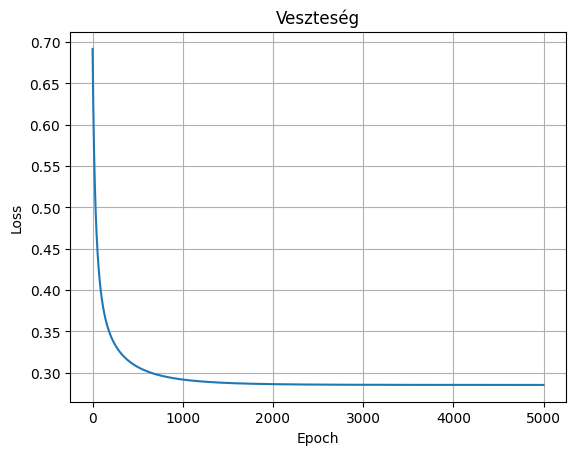

In [42]:
plt.plot(losses)
plt.title("Veszteség")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

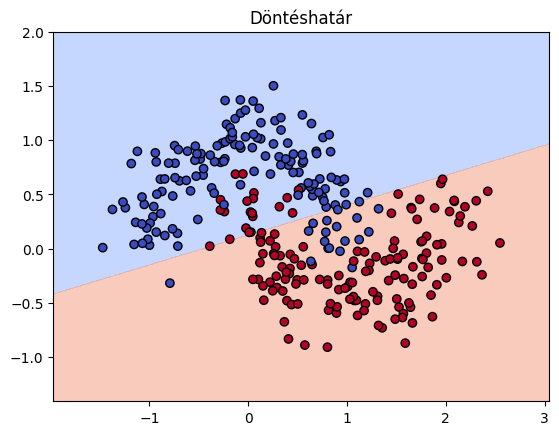

In [43]:
x_min, x_max = X[0, :].min() - 0.5, X[0, :].max() + 0.5
y_min, y_max = X[1, :].min() - 0.5, X[1, :].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000),
                     np.linspace(y_min, y_max, 1000))
Z = sigmoid(w[0] * xx + w[1] * yy + b)
Z = Z > 0.5
plt.contourf(xx, yy, Z, alpha=0.5, cmap="coolwarm")
plt.scatter(X[0, :], X[1, :], c=y.ravel(), cmap="coolwarm", edgecolors='k')
plt.title("Döntéshatár")
plt.show()

## Sekély neurális hálózat

In [44]:
np.random.seed(42)

#bemenet, rejtett rétegbeli elemek száma, kimenet
n_x = X.shape[0]
n_h = 20       # TODO: próbálkozz más értékekkel is! A több rejtett rétegbeli neuronnal a hálózat alkalmas összetett döntéshatárok megtanulására is
n_y = 1

In [45]:
W1 = np.random.randn(n_h, n_x) * 0.01  # (5, 2)
b1 = np.zeros((n_h, 1))                # (?, 1)
W2 = np.random.randn(n_y, n_h) * 0.01  # (1, ?)
b2 = np.zeros((n_y, 1))                # (1, 1)

In [46]:
#sigmoid fentebb már definiálva

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# veszteséget ugyanúgy számoljuk mint fentebb: bináris keresztentrópiával

In [47]:
learning_rate = 0.2
epochs = 5000
losses = []

for epoch in range(epochs):
    Z1 = np.dot(W1, X) + b1          # (?, 300)
    A1 = relu(Z1)                    # (?, 300)
    Z2 = np.dot(W2, A1) + b2          # (1, 300)
    A2 = sigmoid(Z2)                 # (1, 300)

    l = loss(y, A2)
    losses.append(l)

    m = X.shape[1]

    dZ2 = A2 - y                     # (1, 300)
    dW2 = (1/m) * np.dot(dZ2, A1.T)   # (1, 5)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)  # (1, 1)

    dA1 = np.dot(W2.T, dZ2)           # (?, 300)
    dZ1 = dA1 * relu_derivative(Z1)   # (?, 300)
    dW1 = (1/m) * np.dot(dZ1, X.T)    # (?, 2)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)  # (?, 1)

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {l:.4f}")

Epoch 0, Loss: 0.6932
Epoch 500, Loss: 0.2856
Epoch 1000, Loss: 0.2853
Epoch 1500, Loss: 0.2847
Epoch 2000, Loss: 0.2792
Epoch 2500, Loss: 0.2650
Epoch 3000, Loss: 0.2455
Epoch 3500, Loss: 0.1767
Epoch 4000, Loss: 0.1194
Epoch 4500, Loss: 0.0950


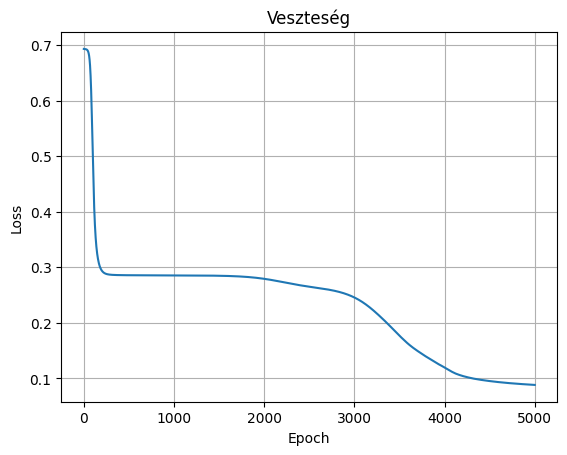

In [48]:
plt.plot(losses)
plt.title("Veszteség")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

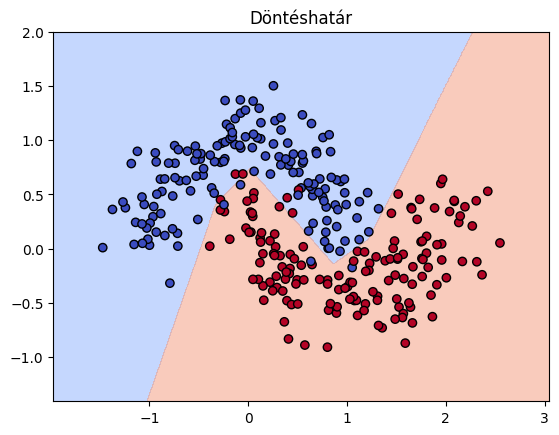

In [49]:
x_min, x_max = X[0, :].min() - 0.5, X[0, :].max() + 0.5
y_min, y_max = X[1, :].min() - 0.5, X[1, :].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000),
                     np.linspace(y_min, y_max, 1000))
grid = np.c_[xx.ravel(), yy.ravel()].T  # (2, 10000)

# Forward pass
Z1 = np.dot(W1, grid) + b1
A1 = relu(Z1)
Z2 = np.dot(W2, A1) + b2
A2 = sigmoid(Z2)

predictions = (A2 > 0.5).reshape(xx.shape)
plt.contourf(xx, yy, predictions, alpha=0.5, cmap="coolwarm")
plt.scatter(X[0, :], X[1, :], c=y.ravel(), cmap="coolwarm", edgecolors="k")
plt.title("Döntéshatár")
plt.show()

### Leaky ReLU

In [50]:
#TODO: a fenti relu cella helyett ez is használható

def relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def relu_derivative(z, alpha=0.01):
    dz = np.ones_like(z)
    dz[z <= 0] = alpha
    return dz

## Többosztályú klasszifikáció

In [51]:
from sklearn.datasets import make_classification

In [52]:
num_classes = 3
X, y = make_classification(n_samples=400, n_classes=num_classes, n_features=2,
                            n_informative=2, n_redundant=0,
                            n_clusters_per_class=1, random_state=42)
X = X.T  # (2, 400)

**One-hot encoding**
A one-hot kódolás során a célváltozó kategóriáit bináris vektorokká alakítjuk. Minden osztály egy külön dimenziót kap, ahol az aktuális osztály pozíciója 1, a többi pedig 0.

Tehát például 3 osztály esetén:
- Osztály 0 → [1, 0, 0]
- Osztály 1 → [0, 1, 0]
- Osztály 2 → [0, 0, 1]

Ez szükséges a softmax kimenet kezeléséhez és a kategórikus kereszt-entrópia kiszámításához.

In [53]:
y.shape

(400,)

In [54]:
y[:5]

array([1, 0, 2, 0, 1])

In [55]:
i = np.eye(3)

In [56]:
i[0], i[1], i[2]

(array([1., 0., 0.]), array([0., 1., 0.]), array([0., 0., 1.]))

In [57]:
i[y[:5]]

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [58]:
Y_onehot = np.eye(num_classes)[y].T  # (3, 400)

In [59]:
np.random.seed(42)
n_x = X.shape[0]   # input size (2)
n_h = 10           # hidden layer size
n_y = num_classes  # output size (3)

W1 = np.random.randn(n_h, n_x) * 0.01  # (10, 2)
b1 = np.zeros((n_h, 1))                # (10, 1)
W2 = np.random.randn(n_y, n_h) * 0.01  # (3, 10)
b2 = np.zeros((n_y, 1))                # (3, 1)

**Softmax**

$\text{softmax}(z) = \cfrac{e^{z}}{\sum e^{z}}$

In [60]:
# relu fentebb definiálva!

def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

**Kategórikus kereszt-entrópia**

A categorical cross-entropy (CCE) a valódi címkék és a softmax által prediktált valószínűségek eltérését méri.

$L = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_{k}^{(i)} \log(\hat{y}_{k}^{(i)})$

ahol:
- $m$ az adatok száma,
- $K$ az osztályok száma,
- $y_{k}^{(i)}$ a valódi one-hot címke az $i$-edik mintára és $k$-adik osztályra,
- $\hat{y}_{k}^{(i)}$ a softmax által becsült valószínűség az $i$-edik mintára és $k$-adik osztályra.

In [61]:
def cce_loss(Y_true, Y_pred):
    m = Y_true.shape[1]
    loss = -np.sum(Y_true * np.log(Y_pred + 1e-8)) / m
    return loss

In [62]:
learning_rate = 0.1
epochs = 5000
losses = []

for epoch in range(epochs):
    Z1 = np.dot(W1, X) + b1         # (?, 400)
    A1 = relu(Z1)                   # (?, 400)
    Z2 = np.dot(W2, A1) + b2         # (3, 400)
    A2 = softmax(Z2)                # (3, 400)

    l = cce_loss(Y_onehot, A2)
    losses.append(l)

    m = X.shape[1]

    dZ2 = A2 - Y_onehot              # (3, 400)
    dW2 = (1/m) * np.dot(dZ2, A1.T)   # (3, 10)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)  # (3, 1)

    dA1 = np.dot(W2.T, dZ2)           # (?, 400)
    dZ1 = dA1 * relu_derivative(Z1)   # (?, 400)
    dW1 = (1/m) * np.dot(dZ1, X.T)    # (?, 2)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)  # (?, 1)

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {l:.4f}")

Epoch 0, Loss: 1.0986
Epoch 500, Loss: 0.3734
Epoch 1000, Loss: 0.3453
Epoch 1500, Loss: 0.3297
Epoch 2000, Loss: 0.3220
Epoch 2500, Loss: 0.3143
Epoch 3000, Loss: 0.3080
Epoch 3500, Loss: 0.3037
Epoch 4000, Loss: 0.3002
Epoch 4500, Loss: 0.2981


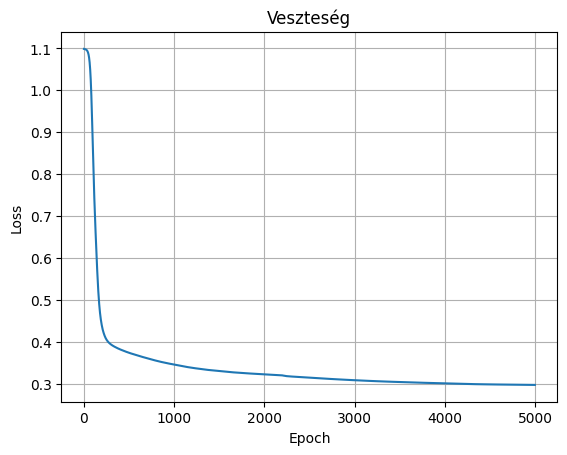

In [63]:
plt.plot(losses)
plt.title("Veszteség")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

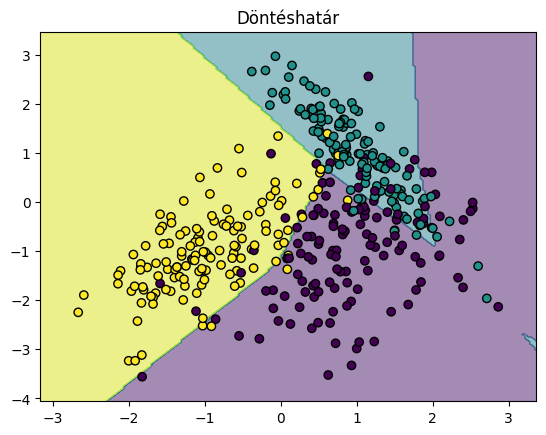

In [64]:
x_min, x_max = X[0, :].min() - 0.5, X[0, :].max() + 0.5
y_min, y_max = X[1, :].min() - 0.5, X[1, :].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()].T  # (2, 40000)

# Forward pass
Z1 = np.dot(W1, grid) + b1
A1 = relu(Z1)
Z2 = np.dot(W2, A1) + b2
A2 = softmax(Z2)

predictions = np.argmax(A2, axis=0).reshape(xx.shape)
plt.contourf(xx, yy, predictions, alpha=0.5,)
plt.scatter(X[0, :], X[1, :], c=y.flatten(), edgecolors="k")
plt.title("Döntéshatár")
plt.show()

## MLPClassifier – Egyszerű neurális háló a scikit-learn-ben

**Fő jellemzők:**
- Több rejtett réteget is támogat (nem csak egyet!)
- Aktivációs függvények: pl. `relu`, `tanh`, `logistic` (=sigmoid)
- Loss függvény: automatikusan választ (pl. cross-entropy osztályozásnál)

---

**Példa használat:**

```python
from sklearn.neural_network import MLPClassifier

# Modell létrehozása: 1 rejtett réteg 10 neuronnal
model = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=1000, random_state=42)
# model = MLPClassifier(hidden_layer_sizes=(10,), activation='logistic', solver='adam', max_iter=1000, random_state=42)

# Betanítás
model.fit(X_train, y_train)

# Előrejelzés
y_pred = model.predict(X_test)
```

---

**Paraméterek:**
- $\texttt{hidden\_layer\_sizes}$: rejtett rétegek mérete, akár több réteg is (pl. (10,) vagy (50, 30))
- $\texttt{activation}$: aktivációs függvény a rejtett rétegekben
- $\texttt{solver}$: az optimalizáló algoritmus
- $\texttt{learning\_rate}$: tanulási ráta 
- $\texttt{max\_iter}$: maximum epoch szám


In [71]:
X, y = make_classification(
    n_samples=400, 
    n_classes=3, 
    n_features=2,
    n_informative=2, 
    n_redundant=0,
    n_clusters_per_class=1, 
    random_state=2
)

In [72]:
# model = MLPClassifier(hidden_layer_sizes=(5,), activation='relu', max_iter=5000, random_state=42)
model = MLPClassifier(hidden_layer_sizes=(500,), activation='logistic', max_iter=5000, random_state=42)
model.fit(X, y)

MLPClassifier(activation='logistic', hidden_layer_sizes=(500,), max_iter=5000,
              random_state=42)

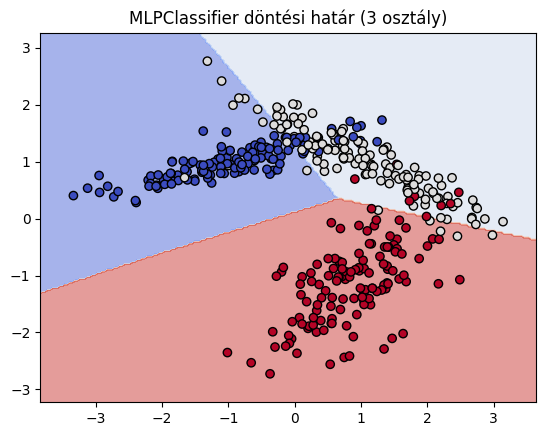

In [73]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
preds = model.predict(grid)
preds = preds.reshape(xx.shape)

plt.contourf(xx, yy, preds, alpha=0.5, cmap="coolwarm")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.title("MLPClassifier döntési határ (3 osztály)")
plt.show()